In [4]:
import astropy.units as u
import astropy.constants as const
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tqdm.notebook import tqdm
import json
import h5py
import os

import warnings
warnings.filterwarnings("ignore")

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model
from DiscEvolution.constants import *

In [7]:
def h5_to_dict(h5obj):
    """Recursively load HDF5 file into nested dict."""
    out = {}
    for k, v in h5obj.items():
        if isinstance(v, h5py.Dataset):
            out[k] = v[()]  # load dataset into memory
        else:
            out[k] = h5_to_dict(v)  # recurse into group
    return out

# Define file paths with descriptive labels (not CR/XR/CX)
file_paths = {
    "1e-7_0.1Msol_50Rd": "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/MiniPopSynth/output/CR_1.0Myr/1e-7_0.1Msol_50Rd/winds_mig_psi2.721e+02_Mdot1.0e-07_M1.0e-01_Rd5.0e+01_20260917_205639.h5",
    "1e-7_0.1Msol_100Rd": "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/MiniPopSynth/output/CR_1.0Myr/1e-7_0.1Msol_100Rd/winds_mig_psi2.721e+02_Mdot1.0e-07_M1.0e-01_Rd5.0e+01_20260917_205647.h5",
    "1e-8_0.1Msol_50Rd": "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/MiniPopSynth/output/CR_1.0Myr/1e-8_0.1Msol_50Rd/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260917_205653.h5",
    "1e-8_0.1Msol_100Rd": "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/MiniPopSynth/output/CR_1.0Myr/1e-8_0.1Msol_100Rd/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260917_205704.h5",
    "1e-9_0.1Msol_50Rd": "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/MiniPopSynth/output/CR_1.0Myr/1e-9_0.1Msol_50Rd/winds_mig_psi6.576e-01_Mdot1.0e-09_M1.0e-01_Rd5.0e+01_20260917_205713.h5",
    "1e-9_0.1Msol_100Rd": "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/MiniPopSynth/output/CR_1.0Myr/1e-9_0.1Msol_100Rd/winds_mig_psi6.576e-01_Mdot1.0e-09_M1.0e-01_Rd5.0e+01_20260917_205725.h5",
}

# Load all files into a single nested dictionary
datasets = {}
for label, path in file_paths.items():
    with h5py.File(path, "r") as f:
        datasets[label] = {
            "data": h5_to_dict(f),
            "attrs": dict(f.attrs),
        }

print(f"✓ Loaded {len(datasets)} simulations")
for label in datasets.keys():
    print(f"  {label}: {list(datasets[label]['data'].keys())}")

✓ Loaded 6 simulations
  1e-7_0.1Msol_50Rd: ['B_xe', 'C_xe', 'D_xe', 'Gamma_C', 'Gamma_L', 'Gamma_N', 'Gamma_T', 'H', 'JXR', 'Lambda', 'M_iso', 'M_transition', 'Mcs', 'Mdot_r', 'Mes', 'NH', 'P', 'R', 'R_dz', 'R_dz_t', 'R_faces', 'Rp', 'Sigc', 'Sigma_G', 'Sigma_dust', 'Sigma_grain_size', 'Sigma_pebble_size', 'Sigma_pebbles', 'Sigma_planetesimals', 'St', 'T', 'Tc', 'Vdrift', 'X_cores', 'X_envs', 'alpha_R', 'disk_Mass', 'disk_Mdot_p', 'disk_Mdot_star', 'disk_atom_gas_abund', 'disk_atom_ice_abund', 'disk_ice_lines', 'disk_mol_gas_abund', 'disk_mol_ice_abund', 'disk_planetesimal_atom_abund', 'disk_planetesimal_mol_abund', 'eta_diff', 'ice_lines', 'n_density', 'nu', 'psi_R', 'rho_mid', 'sigmaXR', 't', 'tau_XR', 'time_snap', 'torque_mass_array', 'v_r', 'xe', 'zeta', 'zeta_CR', 'zeta_XR']
  1e-7_0.1Msol_100Rd: ['B_xe', 'C_xe', 'D_xe', 'Gamma_C', 'Gamma_L', 'Gamma_N', 'Gamma_T', 'H', 'JXR', 'Lambda', 'M_iso', 'M_transition', 'Mcs', 'Mdot_r', 'Mes', 'NH', 'P', 'R', 'R_dz', 'R_dz_t', 'R_faces', '

1e-7_0.1Msol_50Rd: 2101 deadzone snapshots
1e-7_0.1Msol_100Rd: 2101 deadzone snapshots
1e-8_0.1Msol_50Rd: 1178 deadzone snapshots
1e-8_0.1Msol_100Rd: 1178 deadzone snapshots
1e-9_0.1Msol_50Rd: 1138 deadzone snapshots
1e-9_0.1Msol_100Rd: 1138 deadzone snapshots


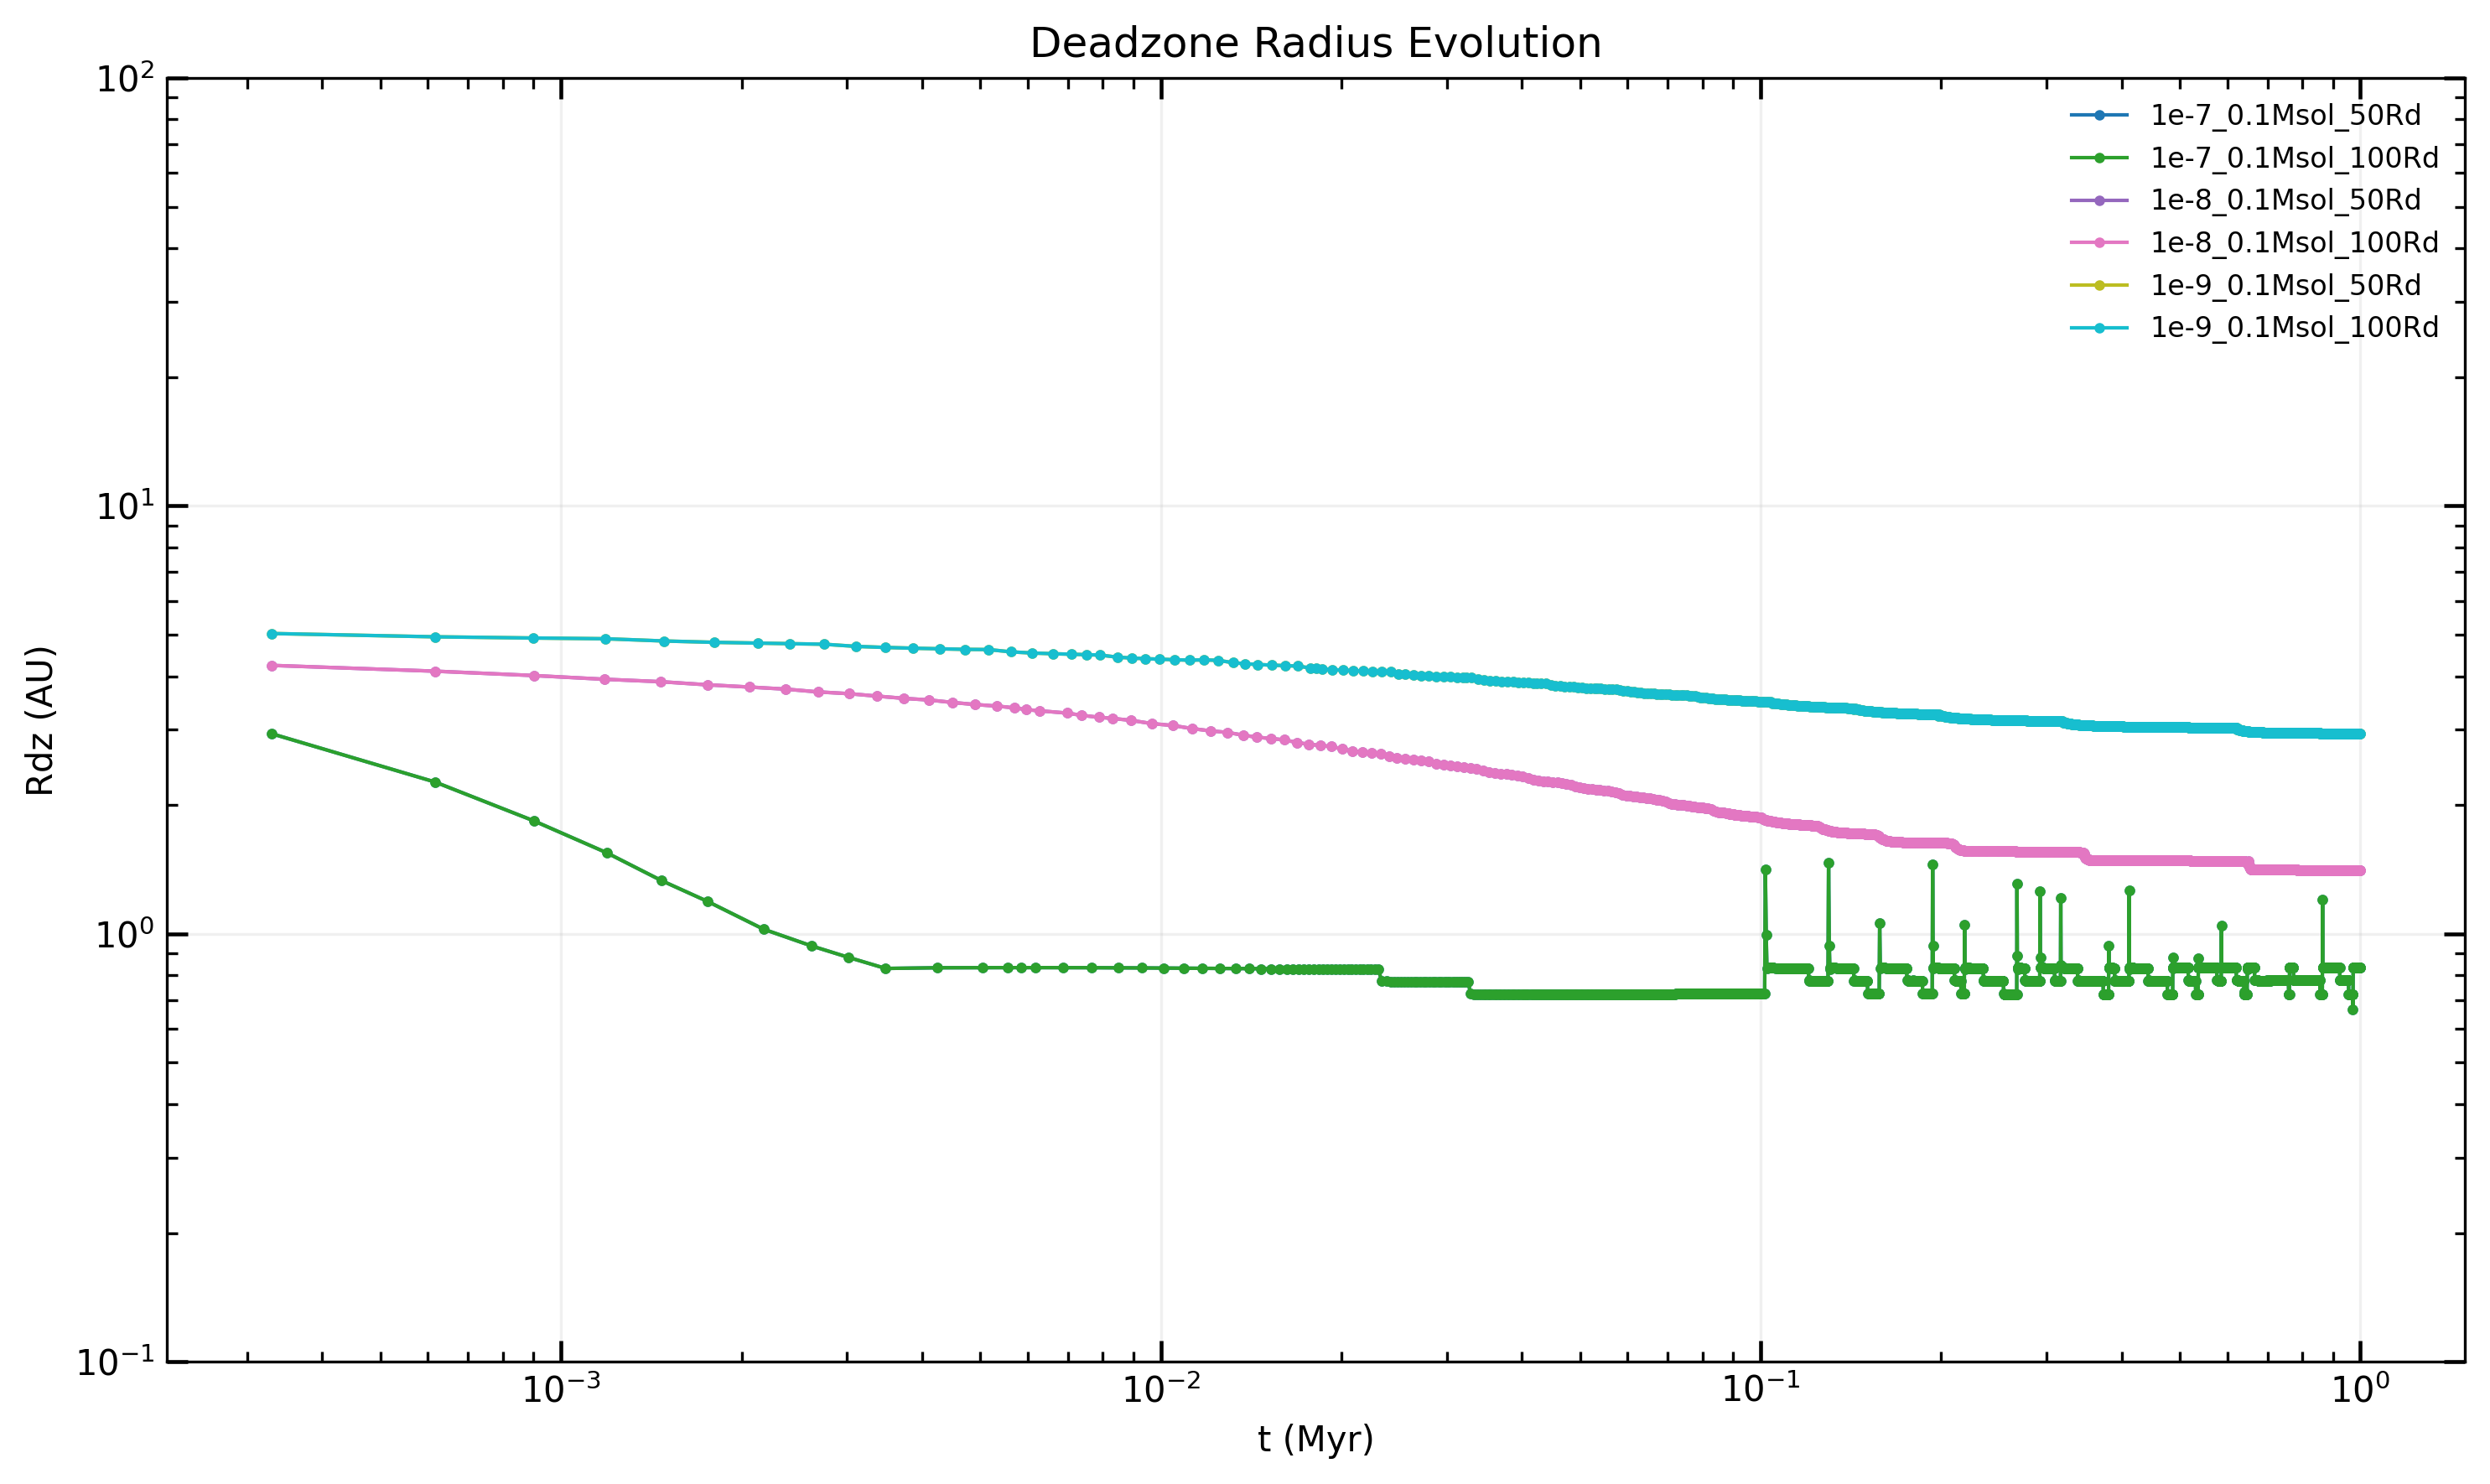


Deadzone radius summary:
  1e-7_0.1Msol_50Rd: 0.665 – 2.938 AU
  1e-7_0.1Msol_100Rd: 0.665 – 2.938 AU
  1e-8_0.1Msol_50Rd: 1.408 – 4.240 AU
  1e-8_0.1Msol_100Rd: 1.408 – 4.240 AU
  1e-9_0.1Msol_50Rd: 2.940 – 5.033 AU
  1e-9_0.1Msol_100Rd: 2.940 – 5.033 AU


In [11]:
# Extract deadzone radius from all loaded simulations
deadzone_data = {}

for label, content in datasets.items():
    data = content["data"]
    R_dz = data.get("R_dz_t", None)
    t = data.get("t", None)  # time array in years
    time_snap = data.get("time_snap", None)  # snapshot times in Myr
    
    if R_dz is not None and t is not None:
        deadzone_data[label] = {
            "R_dz": R_dz,
            "t": t,
            "time_snap": time_snap,
        }
        print(f"{label}: {len(R_dz)} deadzone snapshots")
    else:
        print(f"{label}: Missing R_dz_t or t arrays")

# Example: plot all deadzone radii together
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
ax.set_title('Deadzone Radius Evolution')

colors_map = plt.cm.tab10(np.linspace(0, 1, len(deadzone_data)))

for (label, dz_dict), color in zip(deadzone_data.items(), colors_map):
    t_myr = dz_dict["t"] / 1e6  # Convert years to Myr
    ax.loglog(t_myr, dz_dict["R_dz"], 'o-', color=color, label=label, ms=2, lw=1)

ax.legend(frameon=False, fontsize=8, loc='best')
ax.set_ylim(0.1,100)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nDeadzone radius summary:")
for label, dz_dict in deadzone_data.items():
    R_dz = dz_dict["R_dz"]
    print(f"  {label}: {np.nanmin(R_dz):.3f} – {np.nanmax(R_dz):.3f} AU")